# 01 · EDA & Randomisation Check

The Hillstrom dataset is a **randomised controlled experiment**: 64,000 recent
purchasers were randomly assigned to *Mens E-Mail*, *Womens E-Mail*, or a *No
E-Mail* control. Before we estimate any effect we must confirm two things:

1. the outcomes differ across arms in a way worth analysing, and
2. randomisation actually held — the arms are balanced on pre-treatment
   covariates, so any outcome difference is caused by the e-mail and not by
   pre-existing group differences.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
FIG = Path.cwd().parent / "reports" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from src.data.load import load_raw, ARMS, OUTCOMES
df = load_raw()
print(df.shape)
df.head()

(64000, 12)


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.4400,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0000
1,6,3) $200 - $350,329.0800,1,1,Rural,1,Web,No E-Mail,0,0,0.0000
2,7,2) $100 - $200,180.6500,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0000
3,9,5) $500 - $750,675.8300,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0000
4,2,1) $0 - $100,45.3400,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0000


## Treatment arm sizes
A valid experiment should allocate roughly equally across arms.

In [3]:
arm_counts = df["segment"].value_counts().reindex(ARMS)
print(arm_counts)
print("\nshare:\n", (arm_counts / len(df)).round(4))

segment
No E-Mail        21306
Mens E-Mail      21307
Womens E-Mail    21387
Name: count, dtype: int64

share:
 segment
No E-Mail       0.3329
Mens E-Mail     0.3329
Womens E-Mail   0.3342
Name: count, dtype: float64


## Outcome rates by arm
The headline signal: e-mailed customers visit far more often.

In [4]:
summary = df.groupby("segment")[OUTCOMES].mean().reindex(ARMS)
summary["n"] = df.groupby("segment").size().reindex(ARMS)
summary

,visit,conversion,spend,n
segment,,,,
No E-Mail,0.1062,0.0057,0.6528,21306
Mens E-Mail,0.1828,0.0125,1.4226,21307
Womens E-Mail,0.1514,0.0088,1.0772,21387


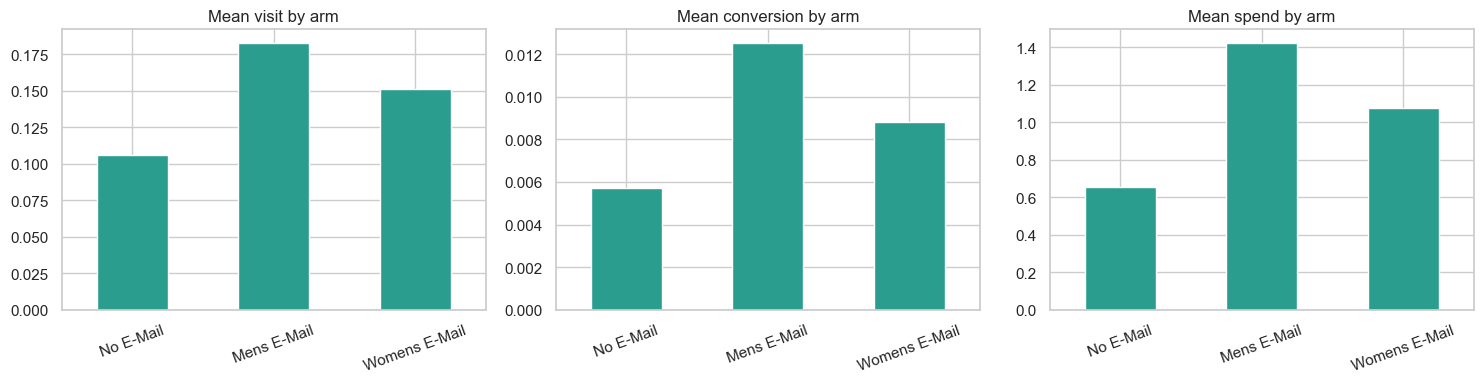

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, OUTCOMES):
    df.groupby("segment")[col].mean().reindex(ARMS).plot(kind="bar", ax=ax, color="#2a9d8f")
    ax.set_title(f"Mean {col} by arm"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.savefig(FIG / "01_outcomes_by_arm.png", dpi=120, bbox_inches="tight"); plt.show()

## Randomisation check — covariate balance

If randomisation worked, the treated and control groups should look identical
*before* treatment. We quantify this with the **standardised mean difference**
(SMD) for each numeric covariate:

$$\text{SMD} = \frac{\bar{x}_{\text{treat}} - \bar{x}_{\text{control}}}{\sqrt{(s^2_{\text{treat}} + s^2_{\text{control}})/2}}$$

The convention is that $|\text{SMD}| < 0.1$ indicates good balance.

In [6]:
from src.data.load import add_treatment_flag
from src.evaluation.plots import plot_balance
two = add_treatment_flag(df)  # Mens E-Mail (1) vs No E-Mail (0)
num_cov = ["recency", "history", "mens", "womens", "newbie"]
rows = {}
for c in num_cov:
    t = two.loc[two.treatment == 1, c]; k = two.loc[two.treatment == 0, c]
    smd = (t.mean() - k.mean()) / np.sqrt((t.var() + k.var()) / 2)
    rows[c] = {"treat_mean": t.mean(), "control_mean": k.mean(), "smd": smd}
balance = pd.DataFrame(rows).T
balance

,treat_mean,control_mean,smd
recency,5.7736,5.7497,0.0068
history,242.8359,240.8827,0.0076
mens,0.5509,0.5532,-0.0046
womens,0.5514,0.5476,0.0076
newbie,0.5015,0.5020,-0.0009


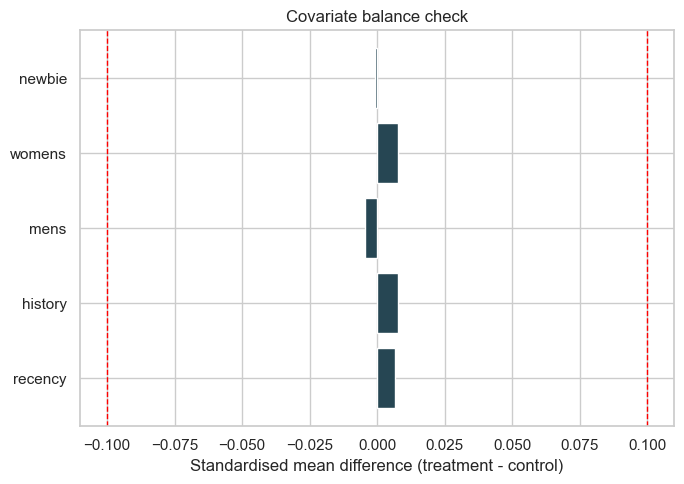

Max |SMD| = 0.0076


In [7]:
ax = plot_balance(balance)
plt.tight_layout(); plt.savefig(FIG / "01_covariate_balance.png", dpi=120, bbox_inches="tight"); plt.show()
print("Max |SMD| =", balance["smd"].abs().max().round(4))

## Takeaways

- The three arms are allocated almost exactly evenly (~1/3 each).
- E-mailed customers visit the site far more than control — there is a real
  effect to quantify in notebook 02.
- All covariate SMDs are well within $\pm0.1$, so **randomisation held**. We
  can attribute outcome differences to the e-mail itself, and a simple
  difference in means is an unbiased estimate of the treatment effect.